In [1]:
import sqlite3
import pandas as pd
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt


In [2]:
inpatient = pd.read_csv("Train_Inpatientdata-1542865627584.csv")
outpatient = pd.read_csv("Train_Outpatientdata-1542865627584.csv")
beneficiary = pd.read_csv("Train_Beneficiarydata-1542865627584.csv")
labels = pd.read_csv("Train-1542865627584.csv")  

conn = sqlite3.connect("claims.db")

inpatient.to_sql("inpatient", conn, if_exists="replace", index=False)
outpatient.to_sql("outpatient", conn, if_exists="replace", index=False)
beneficiary.to_sql("beneficiary", conn, if_exists="replace", index=False)
labels.to_sql("labels", conn, if_exists="replace", index=False)

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables loaded:\n", tables)


Tables loaded:
           name
0    inpatient
1   outpatient
2  beneficiary
3       labels


In [3]:
query = """
SELECT
    Provider,
    COUNT(ClaimID) AS num_claims,
    SUM(InscClaimAmtReimbursed) AS total_reimbursed,
    AVG(InscClaimAmtReimbursed) AS avg_reimbursed,
    COUNT(DISTINCT BeneID) AS num_beneficiaries
FROM (
    SELECT Provider, ClaimID, BeneID, InscClaimAmtReimbursed FROM inpatient
    UNION ALL
    SELECT Provider, ClaimID, BeneID, InscClaimAmtReimbursed FROM outpatient
)
GROUP BY Provider
"""

provider_stats = pd.read_sql(query, conn)
print(f"Aggregated stats for {len(provider_stats)} providers")
print(provider_stats.head())

Aggregated stats for 5410 providers
   Provider  num_claims  total_reimbursed  avg_reimbursed  num_beneficiaries
0  PRV51001          25            104640     4185.600000                 24
1  PRV51003         132            605670     4588.409091                117
2  PRV51004         149             52170      350.134228                138
3  PRV51005        1165            280910      241.124464                495
4  PRV51007          72             33710      468.194444                 58


In [4]:
provider_stats["z_total"] = zscore(provider_stats["total_reimbursed"])
provider_stats["z_avg"] = zscore(provider_stats["avg_reimbursed"])
provider_stats["z_claims"] = zscore(provider_stats["num_claims"])

provider_stats["flagged_zscore"] = (
    (provider_stats["z_total"] > 2) |
    (provider_stats["z_avg"] > 2) |
    (provider_stats["z_claims"] > 2)
)

print(f"Z-score method flagged {provider_stats['flagged_zscore'].sum()} providers")


Z-score method flagged 519 providers


In [5]:
features = provider_stats[["total_reimbursed", "avg_reimbursed", "num_claims", "num_beneficiaries"]]
print(features.dtypes)
print(features.shape)

iso_model = IsolationForest(contamination=0.05, random_state=42)
provider_stats["iso_flag"] = iso_model.fit_predict(features)
provider_stats["flagged_isoforest"] = provider_stats["iso_flag"] == -1

print("Success — column created")
print(provider_stats["flagged_isoforest"].value_counts())

total_reimbursed       int64
avg_reimbursed       float64
num_claims             int64
num_beneficiaries      int64
dtype: object
(5410, 4)
Success — column created
flagged_isoforest
False    5139
True      271
Name: count, dtype: int64


In [6]:
merged = provider_stats.merge(labels, on="Provider", how="left")

def evaluate_method(df, flag_col, label_col="PotentialFraud"):
    overall_rate = (df[label_col] == "Yes").mean()
    flagged_rate = (df[df[flag_col]][label_col] == "Yes").mean()
    print(f"\n--- {flag_col} ---")
    print(f"Overall fraud rate:          {overall_rate:.2%}")
    print(f"Fraud rate among flagged:    {flagged_rate:.2%}")
    print(f"Lift:                        {flagged_rate / overall_rate:.2f}x")
    return overall_rate, flagged_rate

overall_z, flagged_z = evaluate_method(merged, "flagged_zscore")
overall_iso, flagged_iso = evaluate_method(merged, "flagged_isoforest")

print("\nCrosstab (z-score method):")
print(pd.crosstab(merged["flagged_zscore"], merged["PotentialFraud"]))
print("\nCrosstab (Isolation Forest method):")
print(pd.crosstab(merged["flagged_isoforest"], merged["PotentialFraud"]))



--- flagged_zscore ---
Overall fraud rate:          9.35%
Fraud rate among flagged:    46.44%
Lift:                        4.96x

--- flagged_isoforest ---
Overall fraud rate:          9.35%
Fraud rate among flagged:    66.42%
Lift:                        7.10x

Crosstab (z-score method):
PotentialFraud    No  Yes
flagged_zscore           
False           4626  265
True             278  241

Crosstab (Isolation Forest method):
PotentialFraud       No  Yes
flagged_isoforest           
False              4813  326
True                 91  180


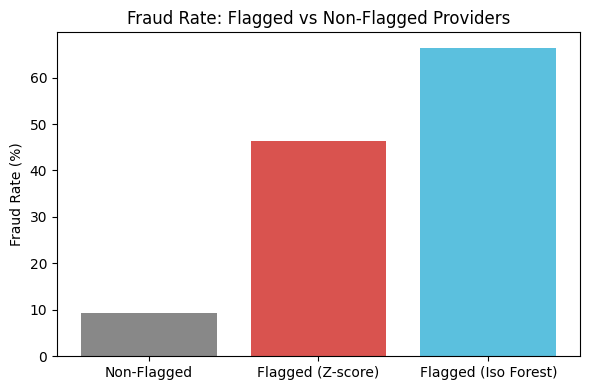


Done. Chart saved as fraud_rate_comparison.png


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ["Non-Flagged", "Flagged (Z-score)", "Flagged (Iso Forest)"],
    [overall_z * 100, flagged_z * 100, flagged_iso * 100],
    color=["#888888", "#d9534f", "#5bc0de"]
)
ax.set_ylabel("Fraud Rate (%)")
ax.set_title("Fraud Rate: Flagged vs Non-Flagged Providers")
plt.tight_layout()
plt.savefig("fraud_rate_comparison.png")
plt.show()


In [8]:
flagged_export = merged[merged["flagged_zscore"] | merged["flagged_isoforest"]]
flagged_export.to_csv("flagged_providers.csv", index=False)
print(f"Exported {len(flagged_export)} flagged providers to flagged_providers.csv")

conn.close()

Exported 526 flagged providers to flagged_providers.csv
